## Hands-on Practice Session: Building an Enhanced Scientific QnA System 
- with OpenAI emeddings and ChromaDB
---
**Environment Setup**

- Ensure your Python environment includes the `openai` library.
- The `OPENAI_API_KEY` must be set in your operating system environment variables.
- For all LLM tasks in this assignment, use the `gpt-4o` model or any other suitable OpenAI model. (This assignment is text-only; no image or audio processing is required.)

#### Data Requirements

Ensure the following files are available in your local folder:
- `claims_train.jsonl`
- `corpus.jsonl`

**About `claims_train.jsonl`**
- Load this file into a pandas DataFrame.
- It contains 809 rows and 4 columns: `['id', 'claim', 'evidence', 'cited_doc_ids']`.
- **claim**: Contains scientific claims, e.g.:
    - "Energy balance requires hypothalamic glutamate neurotransmission."
    - "Glucose restriction to 0.05% reduces RLS (replicative life span) by 20-40% in S. cerevisiae."
- Each claim falls into one of three categories:
    - **Supported:** There is evidence in the dataset that confirms the claim.
    - **Contradicted:** There is evidence in the dataset that disproves the claim.
    - **Not Enough Evidence (NEE):** The dataset does not contain sufficient information to verify or refute the claim.

**About the `evidence` column**
- `cited_doc_ids`: A list of document IDs cited as evidence for a claim (e.g., `[301838, 2734421, 3952288]`).
- Each number refers to a specific document in the dataset.
- The evidence field is a dictionary mapping document IDs to lists of evidence objects, e.g.:

```json
{
  '301838' : [{'sentences': [1], 'label': 'SUPPORT'}, {'sentences': [3], 'label': 'SUPPORT'}],
  '2734421': [{'sentences': [2], 'label': 'SUPPORT'}, ...],
  '3952288': [{'sentences': [3], 'label': 'SUPPORT'}, ...]
}
```
- This means Document 301838, Sentence 1 provides supporting evidence for the claim.
- If the evidence field is an empty dictionary (`{}`), it indicates there is not enough evidence (NEE label).

#### Task: Assess Ground Truth

- Randomly select 100 (or 50) rows from the claims DataFrame.
- For each sampled claim:
    - Examine the `evidence` column.
    - If the evidence contains only `SUPPORT` labels, mark as **True**.
    - If the evidence contains any `CONTRADICT` label, mark as **False**.
    - If the evidence is empty or does not clearly support or contradict, mark as **NEE** (Not Enough Evidence).
- The result should be a list of ground-truth labels for the sampled claims, e.g.:

```
['True', 'False', 'NEE', 'NEE', 'True', 'False', 'True', 'NEE', ...]
```

This list will serve as the reference for evaluating model predictions.

#### Task: Evaluate Claims Using OpenAI LLM

- For the same sample of 100 (or 50) claims, check how the OpenAI LLM (e.g., gpt-4o) processes each claim using its trained knowledge.
- Build a prompt with the following instruction:

  > "I will ask you to assess a scientific claim. Output only the text 'True' if the claim is true, 'False' if the claim is false, or 'NEE' if there's not enough evidence."

- Add a few example shots to the prompt, such as:

  Claim:
  0-dimensional biomaterials show inductive properties.
  Assessment:
  False

  Claim:
  1/2000 in UK have abnormal PrP positivity.
  Assessment:
  True

  Claim:
  Aspirin inhibits the production of PGE2.
  Assessment:
  False

- Write a function that takes each claim and queries the OpenAI LLM (using the `client.chat.completions.create` route) to return the model's response for each claim in the sample.

- Collect the model's responses for all sampled claims for further analysis.

#### Task: Compare Ground Truth with LLM Inferred Output

- Compare the ground-truth labels (from evidence) with the labels inferred by the OpenAI LLM for the sampled claims.
- Visualize the comparison using a confusion matrix to show how well the LLM predictions align with the ground truth.
- Analyze the matrix to identify strengths and weaknesses in the LLM's ability to classify claims as True, False, or NEE.
- Discuss any patterns, such as:
    - Where the LLM tends to agree or disagree with the ground truth
    - Any systematic biases (e.g., overuse of NEE, confusion between True/False)
- Use this analysis to inform further improvements or prompt engineering strategies.
- Assess if the claims can be better validated with more context or additional evidence. (corpus.jsonl)

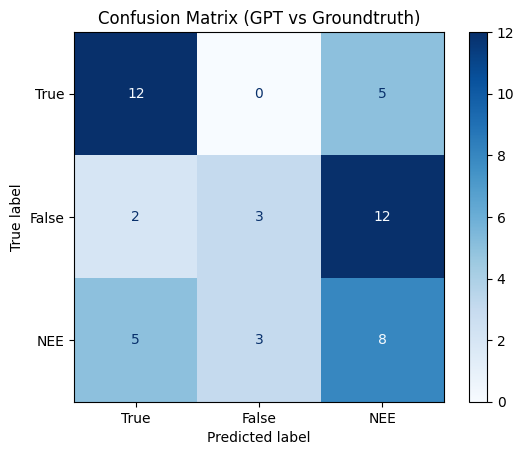

#### Task: Adding Context for Claim Assessment

**Objective:**  
- Enhance the model's ability to assess claims accurately by providing relevant context from external data sources.

**Approach:**  
- Retrieve paper titles and abstracts from the corpus that are related to each claim.
- Present these additional text snippets alongside the claim when querying the LLM.
- Allow the model to leverage this context to:
    - Strengthen its reasoning.
    - Reduce uncertainty in predictions.
    - More reliably distinguish between **True**, **False**, or **Not Enough Evidence (NEE)**.

**Expected Outcome:**  
- With supporting evidence available, the model should:
    - Decrease reliance on baseline memory alone.
    - Lower the number of **NEE** classifications due to lack of knowledge.
    - Improve accuracy in detecting **False claims** by cross-referencing context.

#### Task: Loading Corpus into ChromaDB Vector Store

- Load the corpus into a DataFrame:
  - `corpus_df = pd.read_json(f'{data_path}/corpus.jsonl', lines=True)`
  - The corpus contains 5183 rows and 4 columns: `doc_id`, `title`, `abstract`, `structured`.
- For vector storage, combine the `title` and `abstract` columns for each document.
- Use a batch size of 50 to upload 50 corpus documents at a time into the ChromaDB vector store.
- After uploading, take a sample query (claim) and retrieve the top-3 most relevant documents from the vector store.
- Analyze the retrieved documents to assess their relevance to the query claim.

#### Task: Creating a New Prompt with Additional Context

**Objective:**  
- Improve claim evaluation by updating the prompt to include retrieved context (titles and abstracts from relevant papers).

**Approach:**  
- Modify the prompt construction process as follows:
    1. Retrieve relevant documents (titles and abstracts) from the corpus for each claim.
    2. Combine the claim with the retrieved context in the prompt.
    3. Instruct the model to assess the claim as:
        - **True** → Supported by the provided context.
        - **False** → Contradicted by the provided context.
        - **NEE** → Not enough supporting or contradicting evidence in the context.

**Expected Benefit:**  
- Provides the LLM with external factual information, reducing dependence on baseline memory alone.
- Helps the model make more informed and reliable assessments of claims.
- Should improve precision, particularly for False and NEE cases.

#### Task: Assess Claims with Context and Compare

- Use the `assess_claims_with_context` function, which leverages the new prompt including retrieved context, to evaluate each claim.
- Collect the model's responses for all sampled claims (responses will be 'True', 'False', or 'NEE').
- Generate a confusion matrix comparing these context-aware responses to the ground truth labels.
- Compare this new confusion matrix to the previous one (from the LLM's baseline, context-free assessment).
- Analyze whether providing context improves the model's accuracy, especially for 'False' and 'NEE' cases.